# NYC 311 2025 — Geospatial Analysis

This notebook examines spatial patterns in NYC 311 service requests using borough, community board, and coordinate-level information.

**Analysis period:** January–December 2025


## 1. Load Analytical Dataset



In [1]:
# NYC 311 2025 — GEOSPATIAL ANALYSIS
# Notebook 04

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Clean master analytical dataset
parquet_path = (
    "/content/drive/MyDrive/"
    "NYC_311_2025_BACKUP/"
    "NYC_311_2025_FINAL.parquet"
)

df = pd.read_parquet(parquet_path)

print("NYC 311 2025 — GEOSPATIAL DATASET LOADED")
print("=" * 80)
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
print("=" * 80)


Mounted at /content/drive
NYC 311 2025 — GEOSPATIAL DATASET LOADED
Rows: 3,655,040
Columns: 19


## 2. Geographic Coverage



In [2]:
# STEP 2 — GEOGRAPHIC COVERAGE BASELINE

print("GEOGRAPHIC COVERAGE BASELINE")
print("=" * 80)

total_records = len(df)

borough_records = df["borough"].notna().sum()
community_board_records = df["community_board"].notna().sum()
coordinate_records = (
    df["latitude"].notna()
    & df["longitude"].notna()
).sum()
zip_records = df["incident_zip"].notna().sum()

primary_geography = (
    df["borough"].notna()
    | df["community_board"].notna()
    | (
        df["latitude"].notna()
        & df["longitude"].notna()
    )
).sum()

zip_only = (
    ~(
        df["borough"].notna()
        | df["community_board"].notna()
        | (
            df["latitude"].notna()
            & df["longitude"].notna()
        )
    )
    & df["incident_zip"].notna()
).sum()

no_geography = (
    ~(
        df["borough"].notna()
        | df["community_board"].notna()
        | (
            df["latitude"].notna()
            & df["longitude"].notna()
        )
    )
    & df["incident_zip"].isna()
).sum()

print("TOTAL DATASET")
print("-" * 80)
print("Total records:", f"{total_records:,}")

print("\nGEOGRAPHIC COVERAGE")
print("-" * 80)

print(
    f"Borough available:             {borough_records:,} "
    f"({borough_records / total_records * 100:.2f}%)"
)

print(
    f"Community Board available:     {community_board_records:,} "
    f"({community_board_records / total_records * 100:.2f}%)"
)

print(
    f"Coordinates available:         {coordinate_records:,} "
    f"({coordinate_records / total_records * 100:.2f}%)"
)

print(
    f"ZIP available:                 {zip_records:,} "
    f"({zip_records / total_records * 100:.2f}%)"
)

print("\nANALYSIS COVERAGE")
print("-" * 80)

print(
    f"Primary geographic information: {primary_geography:,} "
    f"({primary_geography / total_records * 100:.2f}%)"
)

print(
    f"ZIP-only information:           {zip_only:,} "
    f"({zip_only / total_records * 100:.2f}%)"
)

print(
    f"No geographic information:      {no_geography:,} "
    f"({no_geography / total_records * 100:.2f}%)"
)

print("\nRECONCILIATION")
print("-" * 80)

print(
    "Coverage total:",
    f"{primary_geography + zip_only + no_geography:,}"
)

if primary_geography + zip_only + no_geography == total_records:
    print("PASS — Geographic coverage fully reconciles.")
else:
    print("CHECK REQUIRED — Geographic coverage does not reconcile.")

print("=" * 80)


GEOGRAPHIC COVERAGE BASELINE
TOTAL DATASET
--------------------------------------------------------------------------------
Total records: 3,655,040

GEOGRAPHIC COVERAGE
--------------------------------------------------------------------------------
Borough available:             3,396,220 (92.92%)
Community Board available:     3,246,595 (88.83%)
Coordinates available:         3,303,394 (90.38%)
ZIP available:                 3,476,461 (95.11%)

ANALYSIS COVERAGE
--------------------------------------------------------------------------------
Primary geographic information: 3,396,377 (92.92%)
ZIP-only information:           229,807 (6.29%)
No geographic information:      28,856 (0.79%)

RECONCILIATION
--------------------------------------------------------------------------------
Coverage total: 3,655,040
PASS — Geographic coverage fully reconciles.


## 3. Borough Demand and Resolution



In [3]:
# STEP 3 — BOROUGH SERVICE DEMAND & RESOLUTION PROFILE

print("BOROUGH SERVICE DEMAND & RESOLUTION PROFILE")
print("=" * 100)

borough_df = (
    df[df["borough"].notna()]
    .groupby("borough")
    .agg(
        requests=("service_request_id", "count"),
        valid_resolution=("resolution_hours", "count"),
        median_resolution_hours=("resolution_hours", "median"),
        p75_resolution_hours=(
            "resolution_hours",
            lambda x: x.quantile(0.75)
        ),
        p90_resolution_hours=(
            "resolution_hours",
            lambda x: x.quantile(0.90)
        )
    )
    .reset_index()
)

borough_df["request_share_pct"] = (
    borough_df["requests"]
    / len(df)
    * 100
).round(2)

borough_df["resolution_coverage_pct"] = (
    borough_df["valid_resolution"]
    / borough_df["requests"]
    * 100
).round(2)

borough_df["median_resolution_days"] = (
    borough_df["median_resolution_hours"] / 24
).round(2)

borough_df["p75_resolution_days"] = (
    borough_df["p75_resolution_hours"] / 24
).round(2)

borough_df["p90_resolution_days"] = (
    borough_df["p90_resolution_hours"] / 24
).round(2)

borough_df = borough_df.sort_values(
    "requests",
    ascending=False
)

print(
    borough_df[
        [
            "borough",
            "requests",
            "request_share_pct",
            "valid_resolution",
            "resolution_coverage_pct",
            "median_resolution_hours",
            "median_resolution_days",
            "p75_resolution_hours",
            "p75_resolution_days",
            "p90_resolution_hours",
            "p90_resolution_days"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 100)
print("BOROUGH ANALYSIS COMPLETE")
print("=" * 100)


BOROUGH SERVICE DEMAND & RESOLUTION PROFILE
      borough  requests  request_share_pct  valid_resolution  resolution_coverage_pct  median_resolution_hours  median_resolution_days  p75_resolution_hours  p75_resolution_days  p90_resolution_hours  p90_resolution_days
     BROOKLYN   1003412              27.45            974009                    97.07                 6.315278                    0.26             71.366667                 2.97            378.780833                15.78
       QUEENS    813632              22.26            784212                    96.38                 4.163611                    0.17             45.826944                 1.91            330.545000                13.77
        BRONX    781563              21.38            768854                    98.37                 9.741667                    0.41             61.653889                 2.57            357.270139                14.89
    MANHATTAN    673197              18.42            646985            

## 4. Borough Request Volume



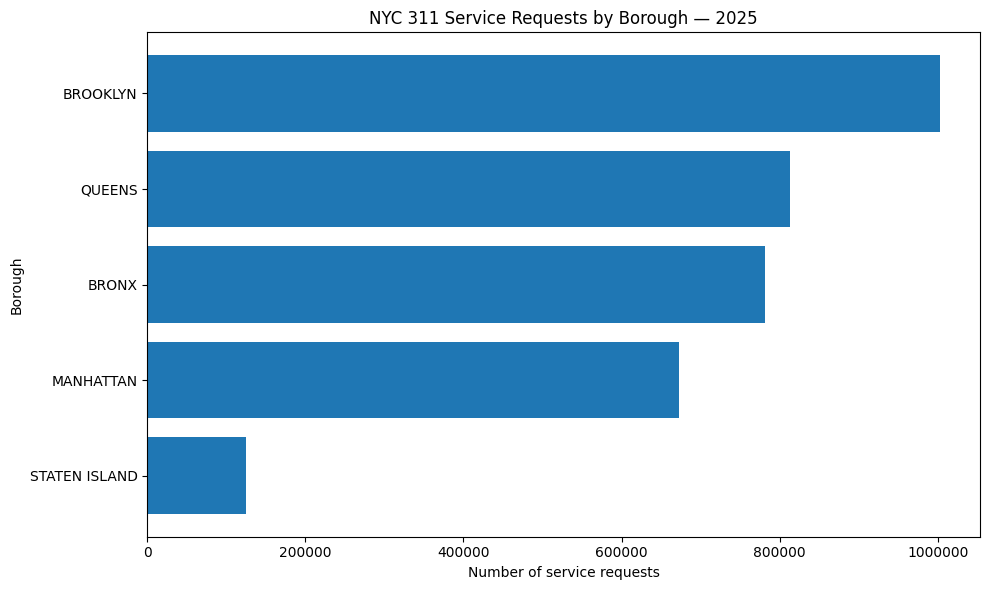

In [4]:
# STEP 4 — BOROUGH REQUEST VOLUME

import matplotlib.pyplot as plt

borough_volume = (
    borough_df
    .sort_values("requests", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    borough_volume["borough"],
    borough_volume["requests"]
)

plt.xlabel("Number of service requests")
plt.ylabel("Borough")
plt.title("NYC 311 Service Requests by Borough — 2025")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()


## 5. Borough Resolution Time



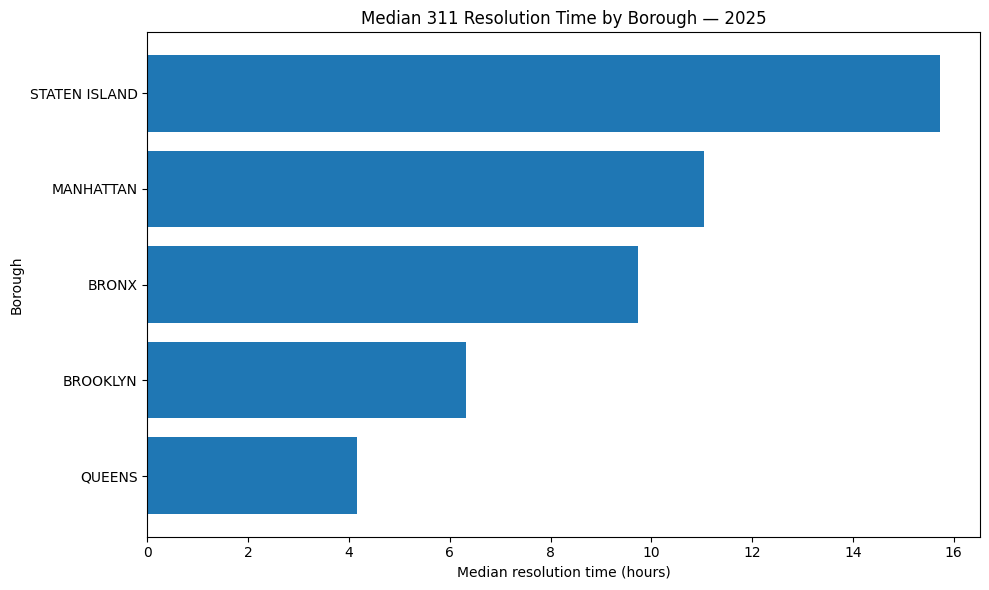

In [5]:
# STEP 5 — BOROUGH MEDIAN RESOLUTION TIME

borough_resolution = (
    borough_df
    .sort_values("median_resolution_hours", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    borough_resolution["borough"],
    borough_resolution["median_resolution_hours"]
)

plt.xlabel("Median resolution time (hours)")
plt.ylabel("Borough")
plt.title("Median 311 Resolution Time by Borough — 2025")

plt.tight_layout()
plt.show()


## 6. Community Board Request Volume



In [6]:
# STEP 6 — COMMUNITY BOARD REQUEST VOLUME

community_board_volume = (
    df.groupby("community_board")
      .size()
      .reset_index(name="requests")
      .sort_values("requests", ascending=False)
)

print("Community boards analyzed:", community_board_volume["community_board"].nunique())
print()
print(community_board_volume.head(15))


Community boards analyzed: 59

   community_board  requests
47        12 BRONX    182831
49    12 MANHATTAN    101122
15        04 BRONX     80797
1      01 BROOKLYN     80680
20     05 BROOKLYN     77251
3        01 QUEENS     76125
41    10 MANHATTAN     75107
50       12 QUEENS     74873
27        07 BRONX     72578
22       05 QUEENS     72306
30       07 QUEENS     71374
6      02 BROOKLYN     70034
34       08 QUEENS     68780
19        05 BRONX     67837
53     14 BROOKLYN     64957


## 7. Top Community Boards by Request Volume



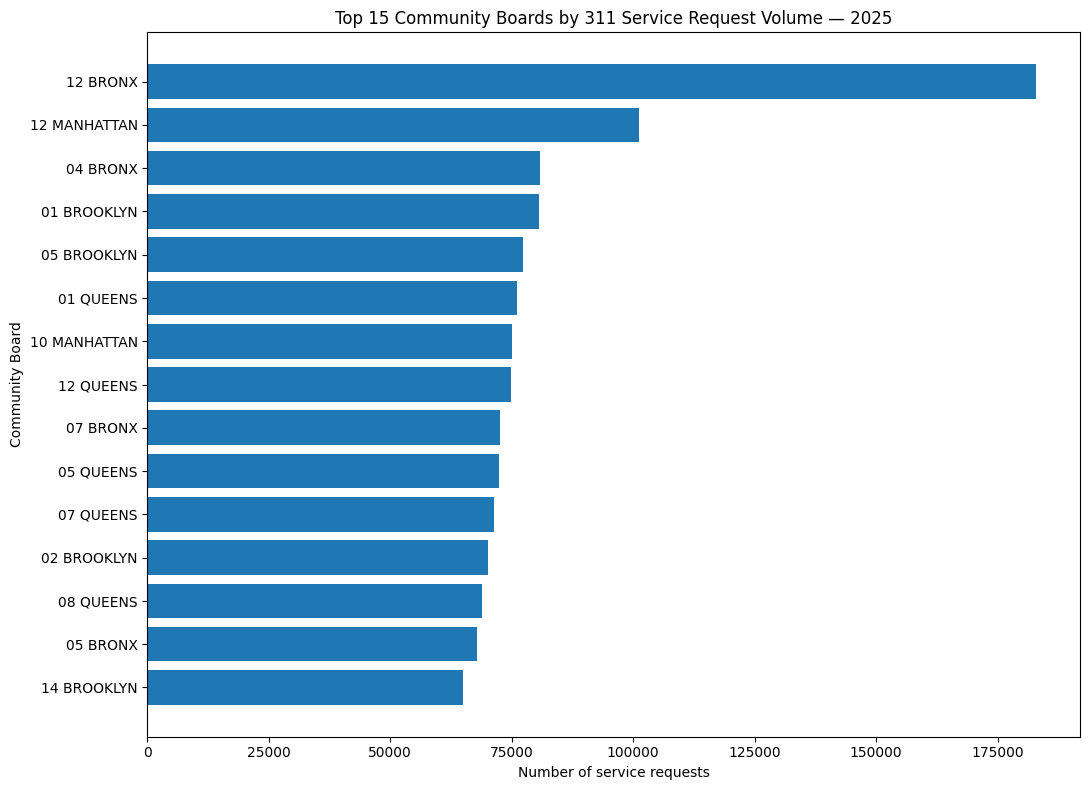

In [7]:
# STEP 7 — TOP 15 COMMUNITY BOARDS BY REQUEST VOLUME

top_15_boards = (
    community_board_volume
    .head(15)
    .sort_values("requests", ascending=True)
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_15_boards["community_board"],
    top_15_boards["requests"]
)

plt.xlabel("Number of service requests")
plt.ylabel("Community Board")
plt.title("Top 15 Community Boards by 311 Service Request Volume — 2025")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()


## 8. Community Board Resolution Profile



In [8]:
# STEP 8 — COMMUNITY BOARD RESOLUTION PROFILE

community_board_resolution = (
    df[df["resolution_hours"].notna()]
    .groupby("community_board")
    .agg(
        requests=("service_request_id", "count"),
        median_resolution_hours=("resolution_hours", "median"),
        p75_resolution_hours=("resolution_hours", lambda x: x.quantile(0.75)),
        p90_resolution_hours=("resolution_hours", lambda x: x.quantile(0.90))
    )
    .reset_index()
)

community_board_resolution["median_resolution_days"] = (
    community_board_resolution["median_resolution_hours"] / 24
)

community_board_resolution["p75_resolution_days"] = (
    community_board_resolution["p75_resolution_hours"] / 24
)

community_board_resolution["p90_resolution_days"] = (
    community_board_resolution["p90_resolution_hours"] / 24
)

print("Community boards analyzed:", community_board_resolution["community_board"].nunique())
print()
print(
    community_board_resolution
    .sort_values("median_resolution_hours", ascending=False)
    .head(15)
)


Community boards analyzed: 59

   community_board  requests  median_resolution_hours  p75_resolution_hours  \
23        06 BRONX     43726                29.482778            154.443056   
5         02 BRONX     24327                26.706389            143.191944   
57     17 BROOKLYN     55572                25.500833            120.966111   
41    10 MANHATTAN     73876                24.937222            116.362569   
15        04 BRONX     79459                24.578889            115.375417   
19        05 BRONX     66891                24.554167            120.457778   
29    07 MANHATTAN     52272                21.264167            149.647500   
0         01 BRONX     40965                21.145556            119.016667   
36     09 BROOKLYN     44142                20.496111             98.180417   
32     08 BROOKLYN     49398                20.227917            110.710069   
27        07 BRONX     71731                19.943333             79.941250   
11     03 BROOKLYN   

## 9. Community Board Resolution Time



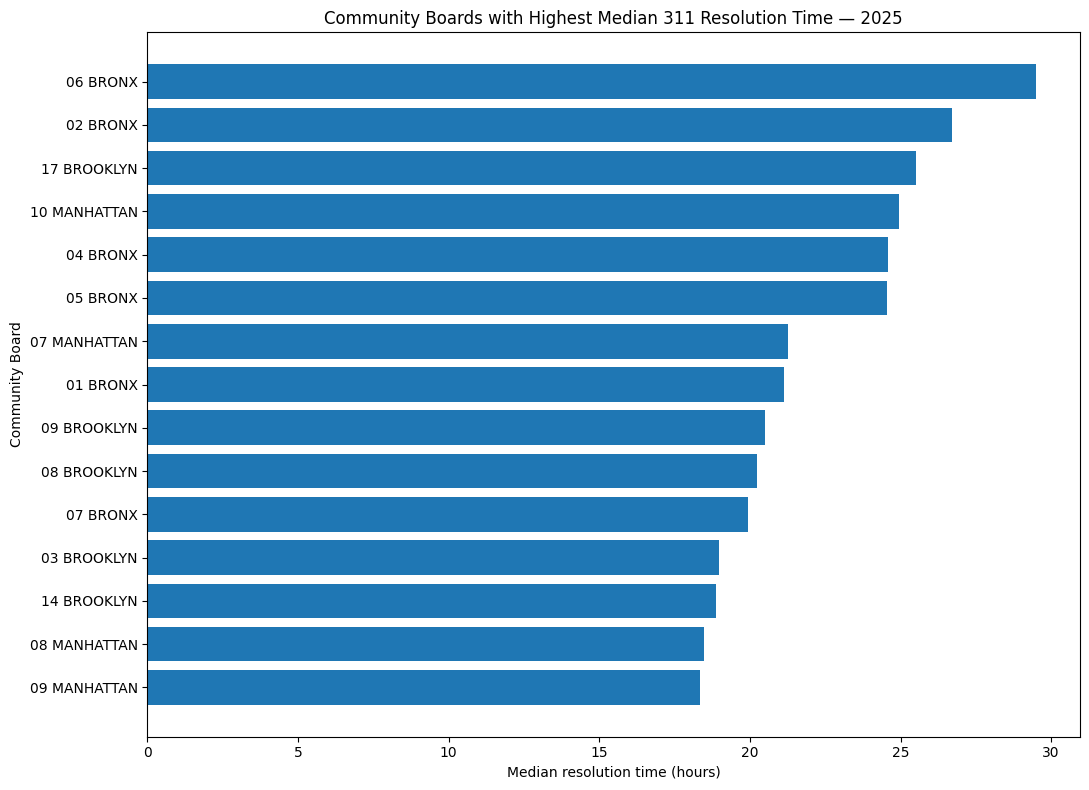

In [9]:
# STEP 9 — COMMUNITY BOARD MEDIAN RESOLUTION TIME

top_15_resolution_boards = (
    community_board_resolution
    .sort_values("median_resolution_hours", ascending=False)
    .head(15)
    .sort_values("median_resolution_hours", ascending=True)
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_15_resolution_boards["community_board"],
    top_15_resolution_boards["median_resolution_hours"]
)

plt.xlabel("Median resolution time (hours)")
plt.ylabel("Community Board")
plt.title("Community Boards with Highest Median 311 Resolution Time — 2025")

plt.tight_layout()
plt.show()


## 10. Coordinate-Level Analysis



In [10]:
geo_df = df[
    df["latitude"].notna()
    & df["longitude"].notna()
].copy()

print("Records with valid coordinates:", len(geo_df))
print(
    "Coordinate coverage:",
    round(len(geo_df) / len(df) * 100, 2),
    "%"
)

print()
print("Latitude range:")
print(geo_df["latitude"].min(), "to", geo_df["latitude"].max())

print()
print("Longitude range:")
print(geo_df["longitude"].min(), "to", geo_df["longitude"].max())


Records with valid coordinates: 3303394
Coordinate coverage: 90.38 %

Latitude range:
40.49891293717068 to 40.912868795316655

Longitude range:
-74.25495171973925 to -73.70036545591262


## 11. Service Request Density



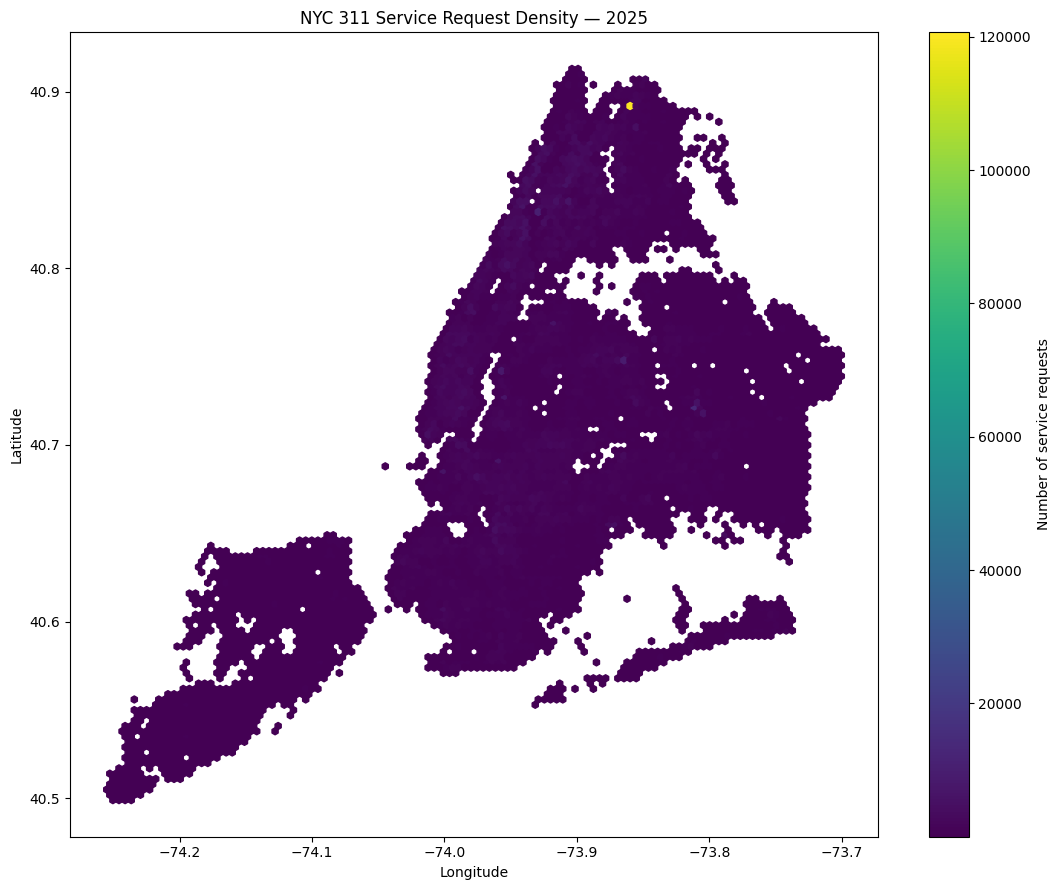

In [11]:
plt.figure(figsize=(11, 9))

plt.hexbin(
    geo_df["longitude"],
    geo_df["latitude"],
    gridsize=120,
    mincnt=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NYC 311 Service Request Density — 2025")

plt.colorbar(
    label="Number of service requests"
)

plt.tight_layout()
plt.show()


## 12. Complaint Types by Borough



In [12]:
# STEP 12 — TOP COMPLAINT TYPES BY BOROUGH

borough_complaints = (
    df[
        df["borough"].notna()
        & df["complaint_type"].notna()
    ]
    .groupby(["borough", "complaint_type"])
    .size()
    .reset_index(name="requests")
)

borough_complaints["borough_total"] = (
    borough_complaints
    .groupby("borough")["requests"]
    .transform("sum")
)

borough_complaints["share_pct"] = (
    borough_complaints["requests"]
    / borough_complaints["borough_total"]
    * 100
)

top_borough_complaints = (
    borough_complaints
    .sort_values(
        ["borough", "requests"],
        ascending=[True, False]
    )
    .groupby("borough")
    .head(5)
)

print(top_borough_complaints.to_string(index=False))


      borough          complaint_type  requests  borough_total  share_pct
        BRONX     Noise - Residential    202811         781451  25.953131
        BRONX          HEAT/HOT WATER    111093         781451  14.216246
        BRONX         Illegal Parking     77656         781451   9.937411
        BRONX Noise - Street/Sidewalk     39016         781451   4.992763
        BRONX    UNSANITARY CONDITION     35659         781451   4.563178
     BROOKLYN         Illegal Parking    210661        1003193  20.999050
     BROOKLYN     Noise - Residential     94519        1003193   9.421816
     BROOKLYN          HEAT/HOT WATER     81158        1003193   8.089969
     BROOKLYN        Blocked Driveway     56900        1003193   5.671890
     BROOKLYN Noise - Street/Sidewalk     35323        1003193   3.521057
    MANHATTAN          HEAT/HOT WATER     75598         672150  11.247192
    MANHATTAN     Noise - Residential     59895         672150   8.910957
    MANHATTAN         Illegal Parking 

## 13. Borough Complaint Mix



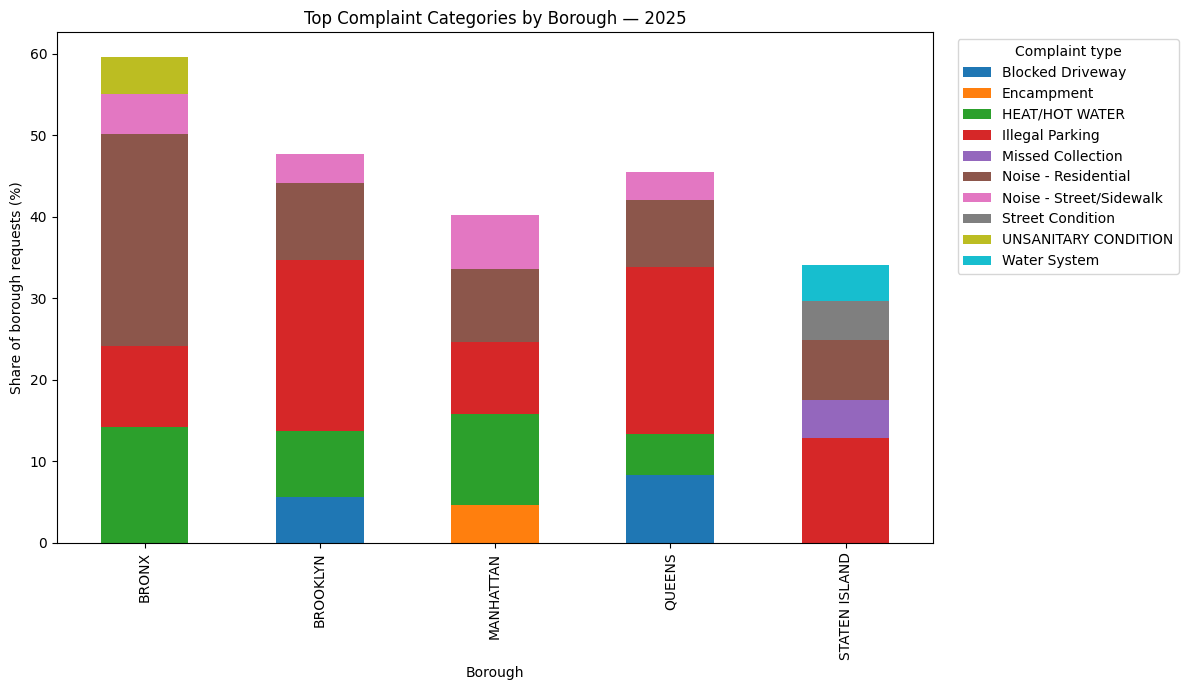

In [13]:
# STEP 13 — BOROUGH COMPLAINT MIX

complaint_mix = (
    top_borough_complaints
    .pivot(
        index="borough",
        columns="complaint_type",
        values="share_pct"
    )
    .fillna(0)
)

complaint_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel("Borough")
plt.ylabel("Share of borough requests (%)")
plt.title("Top Complaint Categories by Borough — 2025")

plt.legend(
    title="Complaint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## 14. Dominant Complaint Type by Community Board



In [14]:
# STEP 14 — DOMINANT COMPLAINT TYPE BY COMMUNITY BOARD

board_complaints = (
    df[
        df["community_board"].notna()
        & df["complaint_type"].notna()
    ]
    .groupby(["community_board", "complaint_type"])
    .size()
    .reset_index(name="requests")
)

board_complaints["board_total"] = (
    board_complaints
    .groupby("community_board")["requests"]
    .transform("sum")
)

board_complaints["share_pct"] = (
    board_complaints["requests"]
    / board_complaints["board_total"]
    * 100
)

dominant_board_complaints = (
    board_complaints
    .sort_values(
        ["community_board", "requests"],
        ascending=[True, False]
    )
    .groupby("community_board")
    .head(1)
    .sort_values("requests", ascending=False)
)

print("Community boards analyzed:", dominant_board_complaints["community_board"].nunique())
print()
print(dominant_board_complaints.to_string(index=False))


Community boards analyzed: 59

 community_board      complaint_type  requests  board_total  share_pct
        12 BRONX Noise - Residential    120693       182830  66.013783
     02 BROOKLYN     Illegal Parking     29513        70021  42.148784
       05 QUEENS     Illegal Parking     23338        72306  32.276713
     11 BROOKLYN     Illegal Parking     21440        61063  35.111279
       02 QUEENS     Illegal Parking     19876        55414  35.868192
    12 MANHATTAN      HEAT/HOT WATER     19855       101115  19.636058
       01 QUEENS     Illegal Parking     18720        76120  24.592748
       09 QUEENS     Illegal Parking     16907        55434  30.499333
     01 BROOKLYN     Illegal Parking     16589        80673  20.563262
     10 BROOKLYN     Illegal Parking     16306        45864  35.552939
     06 BROOKLYN     Illegal Parking     15857        49008  32.355942
        07 BRONX      HEAT/HOT WATER     15770        72571  21.730443
     05 BROOKLYN     Illegal Parking     15562

## 15. Complaint Concentration by Community Board



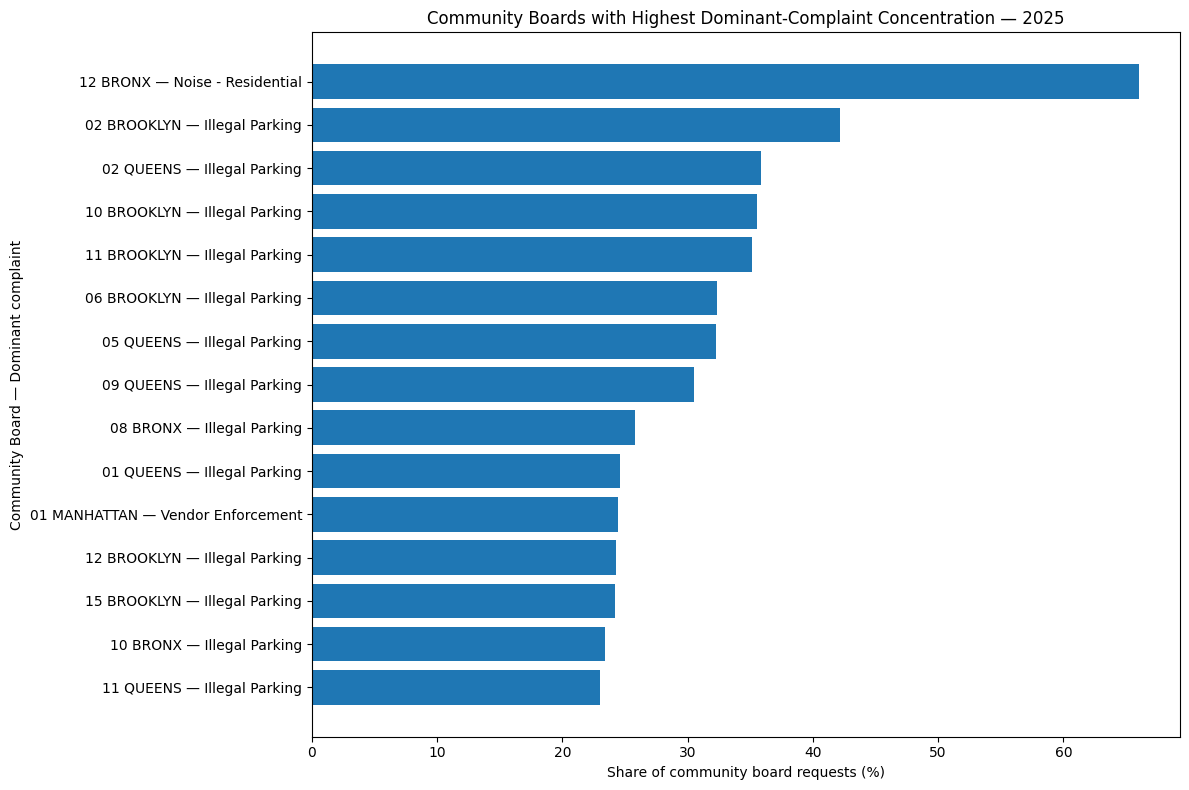

In [15]:
# STEP 15 — COMMUNITY BOARD DOMINANT COMPLAINT CONCENTRATION

top_dominant_boards = (
    dominant_board_complaints
    .sort_values("share_pct", ascending=False)
    .head(15)
    .sort_values("share_pct", ascending=True)
)

plt.figure(figsize=(12, 8))

labels = (
    top_dominant_boards["community_board"]
    + " — "
    + top_dominant_boards["complaint_type"]
)

plt.barh(
    labels,
    top_dominant_boards["share_pct"]
)

plt.xlabel("Share of community board requests (%)")
plt.ylabel("Community Board — Dominant complaint")
plt.title(
    "Community Boards with Highest Dominant-Complaint Concentration — 2025"
)

plt.tight_layout()
plt.show()


## 16. Geographic Coverage of Major Complaint Types



In [16]:
# STEP 16 — MAJOR COMPLAINT TYPES: GEOGRAPHIC COVERAGE

top_5_complaints = (
    df["complaint_type"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 5 complaint types:")
for i, complaint in enumerate(top_5_complaints, 1):
    print(f"{i}. {complaint}")

print()

major_complaint_geo = (
    df[
        df["complaint_type"].isin(top_5_complaints)
        & df["latitude"].notna()
        & df["longitude"].notna()
    ]
    .groupby("complaint_type")
    .agg(
        requests=("service_request_id", "count"),
        unique_boards=("community_board", "nunique"),
        unique_boroughs=("borough", "nunique")
    )
    .reset_index()
)

major_complaint_geo["coordinate_coverage_pct"] = (
    major_complaint_geo["requests"]
    / df[df["complaint_type"].isin(top_5_complaints)]
        .groupby("complaint_type")["service_request_id"]
        .count()
        .reindex(major_complaint_geo["complaint_type"])
        .values
    * 100
)

print(major_complaint_geo.sort_values("requests", ascending=False).to_string(index=False))


Top 5 complaint types:
1. Illegal Parking
2. Noise - Residential
3. HEAT/HOT WATER
4. Blocked Driveway
5. Noise - Street/Sidewalk

         complaint_type  requests  unique_boards  unique_boroughs  coordinate_coverage_pct
        Illegal Parking    523640             59                5                92.749085
    Noise - Residential    425835             59                5                93.262359
         HEAT/HOT WATER    307690             59                5                97.597259
       Blocked Driveway    157374             59                5                93.051335
Noise - Street/Sidewalk    148046             59                5                88.111605


## 17. Major Complaint Spatial Data



In [17]:
# STEP 17 — PREPARE MAJOR COMPLAINT SPATIAL DATA

major_complaint_geo_df = geo_df[
    geo_df["complaint_type"].isin(top_5_complaints)
].copy()

print("Records available for major complaint spatial analysis:",
      len(major_complaint_geo_df))

print()
print(
    major_complaint_geo_df["complaint_type"]
    .value_counts()
)


Records available for major complaint spatial analysis: 1562585

complaint_type
Illegal Parking            523640
Noise - Residential        425835
HEAT/HOT WATER             307690
Blocked Driveway           157374
Noise - Street/Sidewalk    148046
Name: count, dtype: Int64


## 18. Illegal Parking Spatial Density



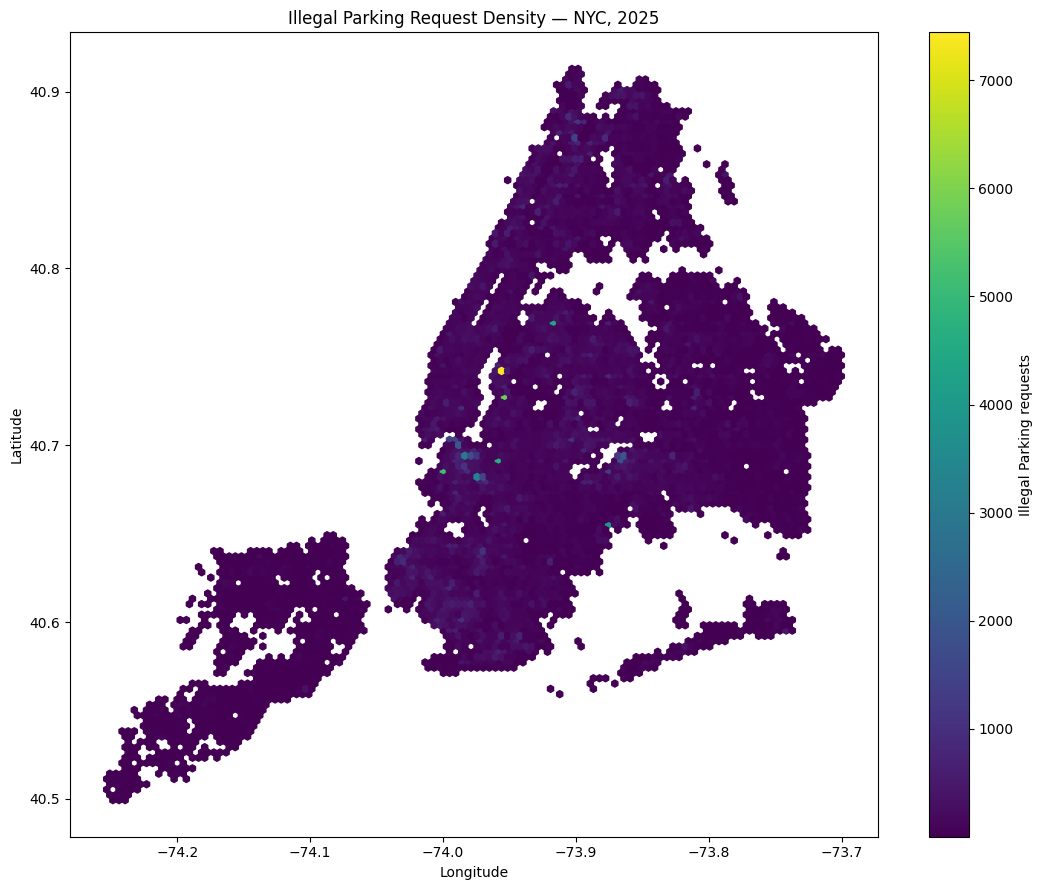

In [18]:
# STEP 18 — ILLEGAL PARKING SPATIAL DENSITY

illegal_parking_geo = major_complaint_geo_df[
    major_complaint_geo_df["complaint_type"] == "Illegal Parking"
]

plt.figure(figsize=(11, 9))

plt.hexbin(
    illegal_parking_geo["longitude"],
    illegal_parking_geo["latitude"],
    gridsize=120,
    mincnt=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Illegal Parking Request Density — NYC, 2025")

plt.colorbar(
    label="Illegal Parking requests"
)

plt.tight_layout()
plt.show()


## 19. Residential Noise Spatial Density



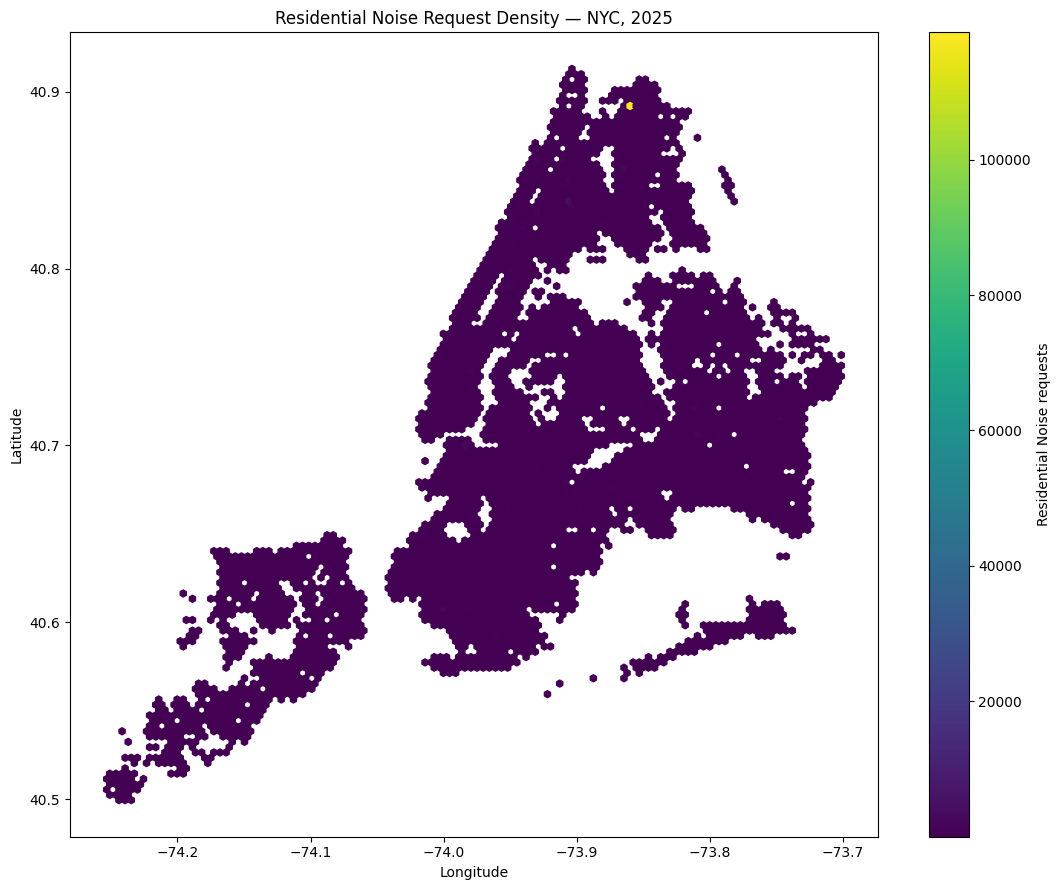

In [19]:
# STEP 19 — RESIDENTIAL NOISE SPATIAL DENSITY

residential_noise_geo = major_complaint_geo_df[
    major_complaint_geo_df["complaint_type"] == "Noise - Residential"
]

plt.figure(figsize=(11, 9))

plt.hexbin(
    residential_noise_geo["longitude"],
    residential_noise_geo["latitude"],
    gridsize=120,
    mincnt=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Residential Noise Request Density — NYC, 2025")

plt.colorbar(
    label="Residential Noise requests"
)

plt.tight_layout()
plt.show()


## 20. Heat / Hot Water Spatial Density



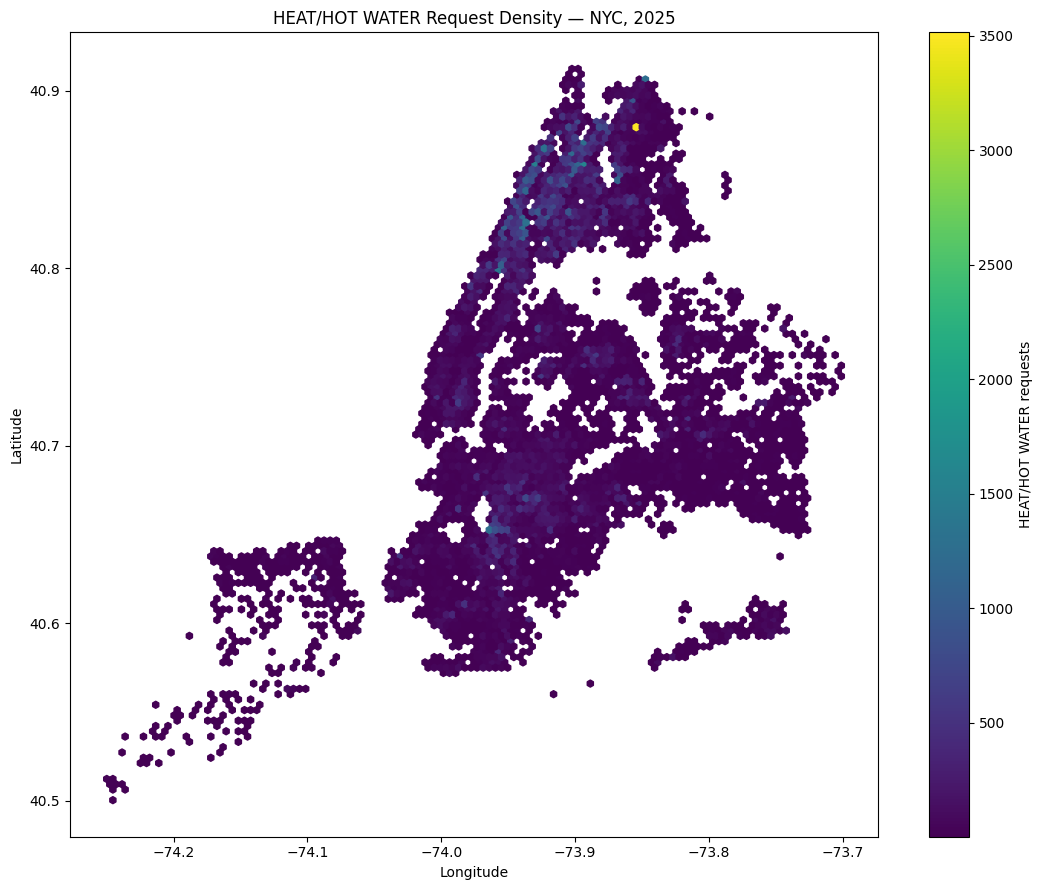

In [20]:
# STEP 20 — HEAT/HOT WATER SPATIAL DENSITY

heat_hot_water_geo = major_complaint_geo_df[
    major_complaint_geo_df["complaint_type"] == "HEAT/HOT WATER"
]

plt.figure(figsize=(11, 9))

plt.hexbin(
    heat_hot_water_geo["longitude"],
    heat_hot_water_geo["latitude"],
    gridsize=120,
    mincnt=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("HEAT/HOT WATER Request Density — NYC, 2025")

plt.colorbar(
    label="HEAT/HOT WATER requests"
)

plt.tight_layout()
plt.show()


## 21. Borough Geospatial Summary



In [21]:
# STEP 21 — BOROUGH GEOSPATIAL SUMMARY

borough_geo_summary = (
    df.groupby("borough")
      .agg(
          total_requests=("service_request_id", "count"),
          requests_with_coordinates=("latitude", "count"),
          requests_with_community_board=("community_board", "count"),
          requests_with_zip=("incident_zip", "count"),
          median_resolution_hours=("resolution_hours", "median"),
          p75_resolution_hours=("resolution_hours", lambda x: x.quantile(0.75)),
          p90_resolution_hours=("resolution_hours", lambda x: x.quantile(0.90))
      )
      .reset_index()
)

borough_geo_summary["coordinate_coverage_pct"] = (
    borough_geo_summary["requests_with_coordinates"]
    / borough_geo_summary["total_requests"]
    * 100
)

borough_geo_summary["community_board_coverage_pct"] = (
    borough_geo_summary["requests_with_community_board"]
    / borough_geo_summary["total_requests"]
    * 100
)

borough_geo_summary["zip_coverage_pct"] = (
    borough_geo_summary["requests_with_zip"]
    / borough_geo_summary["total_requests"]
    * 100
)

borough_geo_summary["median_resolution_days"] = (
    borough_geo_summary["median_resolution_hours"] / 24
)

borough_geo_summary["p75_resolution_days"] = (
    borough_geo_summary["p75_resolution_hours"] / 24
)

borough_geo_summary["p90_resolution_days"] = (
    borough_geo_summary["p90_resolution_hours"] / 24
)

print(borough_geo_summary.to_string(index=False))


      borough  total_requests  requests_with_coordinates  requests_with_community_board  requests_with_zip  median_resolution_hours  p75_resolution_hours  p90_resolution_hours  coordinate_coverage_pct  community_board_coverage_pct  zip_coverage_pct  median_resolution_days  p75_resolution_days  p90_resolution_days
        BRONX          781563                     761551                         748079             746007                 9.741667             61.653889            357.270139                97.439490                     95.715764         95.450655                0.405903             2.568912            14.886256
     BROOKLYN         1003412                     978607                         964915             963202                 6.315278             71.366667            378.780833                97.527935                     96.163391         95.992673                0.263137             2.973611            15.782535
    MANHATTAN          673197                     65664

## 22. Community Board Geospatial Summary



In [22]:
# STEP 22 — COMMUNITY BOARD GEOSPATIAL SUMMARY

community_board_geo_summary = (
    df.groupby("community_board")
      .agg(
          total_requests=("service_request_id", "count"),
          requests_with_coordinates=("latitude", "count"),
          requests_with_zip=("incident_zip", "count"),
          median_resolution_hours=("resolution_hours", "median"),
          p75_resolution_hours=("resolution_hours", lambda x: x.quantile(0.75)),
          p90_resolution_hours=("resolution_hours", lambda x: x.quantile(0.90))
      )
      .reset_index()
)

community_board_geo_summary["coordinate_coverage_pct"] = (
    community_board_geo_summary["requests_with_coordinates"]
    / community_board_geo_summary["total_requests"]
    * 100
)

community_board_geo_summary["zip_coverage_pct"] = (
    community_board_geo_summary["requests_with_zip"]
    / community_board_geo_summary["total_requests"]
    * 100
)

community_board_geo_summary["median_resolution_days"] = (
    community_board_geo_summary["median_resolution_hours"] / 24
)

community_board_geo_summary["p75_resolution_days"] = (
    community_board_geo_summary["p75_resolution_hours"] / 24
)

community_board_geo_summary["p90_resolution_days"] = (
    community_board_geo_summary["p90_resolution_hours"] / 24
)

print("Community boards:", len(community_board_geo_summary))
print()
print(community_board_geo_summary.head(10).to_string(index=False))


Community boards: 59

 community_board  total_requests  requests_with_coordinates  requests_with_zip  median_resolution_hours  p75_resolution_hours  p90_resolution_hours  coordinate_coverage_pct  zip_coverage_pct  median_resolution_days  p75_resolution_days  p90_resolution_days
        01 BRONX           41543                      41409              41227                21.145556            119.016667            641.851500                99.677443         99.239342                0.881065             4.959028            26.743812
     01 BROOKLYN           80680                      80282              79951                 3.676944             69.719306            470.882667                99.506693         99.096430                0.153206             2.904971            19.620111
    01 MANHATTAN           30653                      30384              30328                 0.937917             21.810000            209.794917                99.122435         98.939745                0

## Conclusion

The geospatial analysis identifies geographic differences in service demand, resolution performance, and complaint composition across NYC.
